In [ ]:
import numpy as np

class BoxTable:

    def __init__(self, means, noise_std=0.0, seed=0):
        self.means = np.asarray(means, dtype=float)  # one mean per box/arm
        self.nA = self.means.shape[0]
        self.noise_std = float(noise_std)
        self.rng = np.random.default_rng(seed)

    def __getitem__(self, a):
        """
        a is expected to be a one-hot vector (or close to it).
        We map it to an arm index via argmax.
        """
        a = np.asarray(a)
        idx = int(np.argmax(a))  # box index
        noise = self.rng.normal(0.0, self.noise_std)
        return float(self.means[idx] + noise)


def make_tabular_box_environment(mu_r, mu_u, noise_r=0.0, noise_u=0.0, seed=0):
    """
    Returns (actions, R, U).

    actions: one-hot vectors (nA x nA), can sample ak as a vector.
    R: BoxTable that returns reward when indexed by ak
    U: BoxTable that returns utility when indexed by ak
    """
    mu_r = np.asarray(mu_r, dtype=float)
    mu_u = np.asarray(mu_u, dtype=float)
    assert mu_r.shape == mu_u.shape

    nA = mu_r.shape[0]
    actions = np.eye(nA)  # one-hot representation for each box

    R = BoxTable(mu_r, noise_std=noise_r, seed=seed + 1)
    U = BoxTable(mu_u, noise_std=noise_u, seed=seed + 2)

    return actions, R, U


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sun Dec 21 01:08:59 2025

@author: Sourav
"""

import numpy as np
class constrained_KL_reg:
    def __init__(self,beta_r,beta_g,lambda_,tau,rho,kappa,K,a,nA,actions,b,R,U):
        self.beta_r = beta_r
        self.beta_g = beta_g
        self.lambda_ = lambda_
        self.tau = tau
        self.rho = rho
        self.kappa = kappa
        self.K = K
        self.a = a
        self.nA = nA
        self.actions = actions
        self.pi_ref = np.ones(self.nA)/self.nA
        self.b = b
        self.R = R
        self.U = U
    def special_initialization(self,init_policy=None,Lambda = None,thetar=None,thetag=None):
        if(init_policy==None):
            self.pi = np.ones(self.nA)/self.nA
        else:
            self.pi = init_policy

        if(Lambda==None):
            self.Lambda = self.rho*np.eye(len(self.actions[1])) #need size here
        else:
            self.Lambda = Lambda
    def calculate_theta(self,a,j):
        a = np.array(a)
        lam_inv = np.linalg.inv(self.Lambda)
        add = np.zeros(len(a[0]))
        for i in range(len(a)):
            add = add + a[i]*j[i]  ###Confirm will it be reward/cost value of theta itself?
        return np.matmul(lam_inv,add)
    def update_policy(self,g_hat,r_hat):
        g_expect = np.sum([self.pi[i]*g_hat[i] for i in range(self.nA)])
        z = (self.b - g_expect)/self.tau
        exp_term = np.exp((r_hat-self.kappa+self.lambda_*self.tau*np.exp(z)*g_hat/(1+np.exp(z)))*1/self.kappa)#Cheeck this term
        pi_new = self.pi_ref*exp_term #Check this term
        pi_new = pi_new/np.sum(pi_new)
        return pi_new
    def run_algo(self):
        action_arr = []
        rew_arr = []
        utility_arr = []
        for k in range(self.K):
            print(k,"=>",self.pi)
            ak = self.actions[np.random.choice(self.nA,p=self.pi)]
            action_arr.append(ak)
            rew_arr.append(self.R[ak])
            utility_arr.append(self.U[ak])
            theta_r,theta_g = self.calculate_theta(action_arr,rew_arr),self.calculate_theta(action_arr,utility_arr)
            r_hat = []
            g_hat = []
            for a in self.actions:
                r_hat.append(np.dot(a,theta_r)+self.beta_r*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a))))
                g_hat.append(np.dot(a,theta_g)+self.beta_g*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a))))
            #rew_arr.append(r_hat,g_hat)
            self.pi = self.update_policy(g_hat,r_hat)
            self.Lambda = self.Lambda + np.matmul(ak,np.transpose(ak))
        return action_arr,rew_arr,utility_arr

###STILL UNSOLVED QUESTION
##1) Solving the calculate_theta
###2) Updating policy (Only calculation is left)
###3) What to return and how?
###4) What will be the choice of action? UCB, TS or something else?
###5) How to update pi_ref?

In [ ]:

if __name__ == "__main__":

    mu_r = [0.95, 0.70, 0.55]
    mu_u = [0.20, 0.80, 0.95]

    # constraint threshold b
    b = 0.60

    # Build environment objects compatible with R[ak], U[ak]
    actions, R, U = make_tabular_box_environment(mu_r, mu_u, noise_r=0.05, noise_u=0.05, seed=0)
    nA = actions.shape[0]

    # Create  agent
    agent = constrained_KL_reg(
        beta_r=1.0,
        beta_g=1.0,
        lambda_=5.0,
        tau=1.0,
        rho=1.0,
        kappa=30.0,
        K=1000,
        a=None,
        nA=nA,
        actions=actions,
        b=b,
        R=R,
        U=U
    )

    agent.special_initialization()

    _orig_update_policy = agent.update_policy
    def _wrapped_update_policy(g_hat, r_hat):
        return _orig_update_policy(np.asarray(g_hat, dtype=float), np.asarray(r_hat, dtype=float))
    agent.update_policy = _wrapped_update_policy

    # Run
    actions,rew_arr,utility_arr = agent.run_algo()

    print("Run finished.")
    print("Final pi:", np.round(agent.pi, 4))
    print("Final Lambda (shape):", agent.Lambda.shape)


0 => [0.33333333 0.33333333 0.33333333]
1 => [0.32176831 0.35646338 0.32176831]
2 => [0.30914135 0.38171731 0.30914135]
3 => [0.31976548 0.37634876 0.30388576]
4 => [0.30962382 0.36436426 0.32601192]
5 => [0.29618877 0.39196831 0.31184292]
6 => [0.30855339 0.38520674 0.30623987]
7 => [0.29749717 0.37128341 0.33121942]
8 => [0.30957448 0.36493642 0.3254891 ]
9 => [0.32132078 0.35875614 0.31992309]
10 => [0.30908429 0.38319544 0.30772028]
11 => [0.29564706 0.4100339  0.29431904]
12 => [0.3064933  0.40379008 0.28971662]
13 => [0.29348915 0.42909807 0.27741278]
14 => [0.28048044 0.45441088 0.26510868]
15 => [0.29147834 0.44754466 0.26097699]
16 => [0.30250803 0.44065053 0.25684144]
17 => [0.29288757 0.42645116 0.28066126]
18 => [0.27987975 0.45193759 0.26818266]
19 => [0.27089061 0.43724882 0.29186057]
20 => [0.28030248 0.43165443 0.28804309]
21 => [0.26673041 0.45920128 0.2740683 ]
22 => [0.25789465 0.44381843 0.29828692]
23 => [0.24514077 0.47135364 0.28350559]
24 => [0.23231536 0.499038

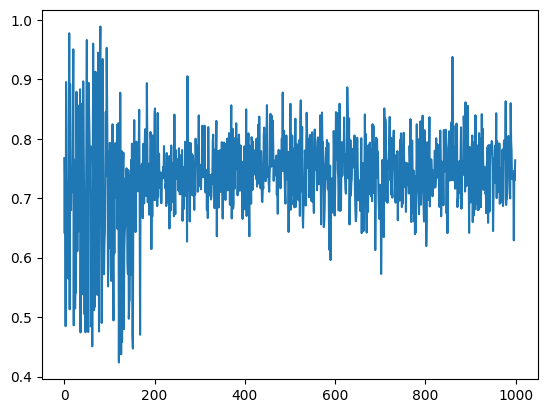

In [ ]:
import matplotlib.pyplot as plt
plt.plot(rew_arr)

In [ ]:
plt.figure()
plt.plot(rew_arr)
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.title("Reward vs Iteration")

plt.savefig("3arm_reward.pdf", bbox_inches="tight")
plt.close()

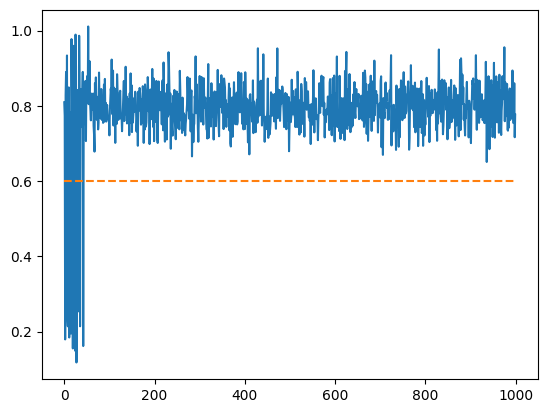

In [ ]:

plt.plot(utility_arr)
plt.plot(np.ones(len(utility_arr))*b,'--')

In [ ]:
plt.figure()
plt.plot(utility_arr, label="Utility")
plt.plot(np.ones(len(utility_arr)) * b, '--', label="Threshold b")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Utility")
plt.title("Utility vs Iteration")

plt.savefig("3arm_utility.pdf", bbox_inches="tight")
plt.close()

In [ ]:
print([np.argmax(actions[i]) for i in range(len(actions))])

[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1)

In [ ]:
print(np.argmax(actions[0]))

0


**For 10 Arms**

In [ ]:

if __name__ == "__main__":

    mu_r = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50]
    mu_u = [0.20, 0.30, 0.40, 0.55, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

    # constraint threshold b
    b = 0.60

    # Build environment objects compatible with R[ak], U[ak]
    actions, R, U = make_tabular_box_environment(mu_r, mu_u, noise_r=0.05, noise_u=0.05, seed=0)
    nA = actions.shape[0]

    # Create  agent
    agent = constrained_KL_reg(
        beta_r=1.0,
        beta_g=1.0,
        lambda_=5.0,
        tau=3.0,
        rho=1.0,
        kappa=35.0,
        K=1000,
        a=None,
        nA=nA,
        actions=actions,
        b=b,
        R=R,
        U=U
    )

    agent.special_initialization()

    _orig_update_policy = agent.update_policy
    def _wrapped_update_policy(g_hat, r_hat):
        return _orig_update_policy(np.asarray(g_hat, dtype=float), np.asarray(r_hat, dtype=float))
    agent.update_policy = _wrapped_update_policy

    # Run
    actions,rew_arr,utility_arr = agent.run_algo()

    print("Run finished.")
    print("Final pi:", np.round(agent.pi, 4))
    print("Final Lambda (shape):", agent.Lambda.shape)


0 => [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
1 => [0.09873371 0.09873371 0.11139665 0.09873371 0.09873371 0.09873371
 0.09873371 0.09873371 0.09873371 0.09873371]
2 => [0.09659635 0.09659635 0.10903286 0.09659635 0.09659635 0.09659635
 0.11819634 0.09659635 0.09659635 0.09659635]
3 => [0.09502152 0.09502152 0.10725894 0.09502152 0.11131356 0.09502152
 0.11627688 0.09502152 0.09502152 0.09502152]
4 => [0.09297124 0.09297124 0.10494468 0.09297124 0.10891184 0.09297124
 0.11376809 0.09297124 0.11454794 0.09297124]
5 => [0.09151711 0.09151711 0.11893675 0.09151711 0.10721023 0.09151711
 0.11199126 0.09151711 0.11275911 0.09151711]
6 => [0.08905117 0.08905117 0.11573123 0.08905117 0.104321   0.08905117
 0.13592058 0.08905117 0.10972015 0.08905117]
7 => [0.08780586 0.08780586 0.11411423 0.10178365 0.10286297 0.08780586
 0.13402285 0.08780586 0.10818702 0.08780586]
8 => [0.08617931 0.08617931 0.1120003  0.09989815 0.10095748 0.10470385
 0.1315401  0.08617931 0.1061829  0.08617931]
9 => [0.0

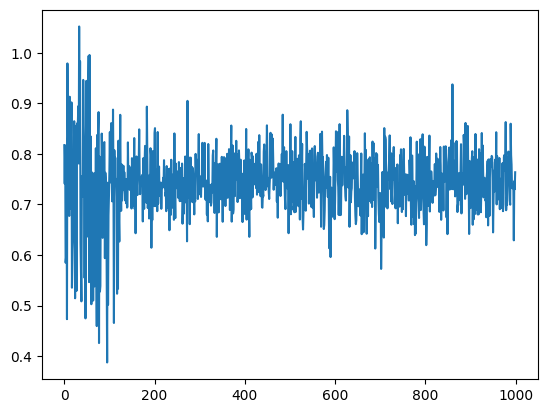

In [ ]:
import matplotlib.pyplot as plt
plt.plot(rew_arr)

In [ ]:
plt.figure()
plt.plot(rew_arr)
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.title("Reward vs Iteration")

plt.savefig("10arm_reward.pdf", bbox_inches="tight")
plt.close()

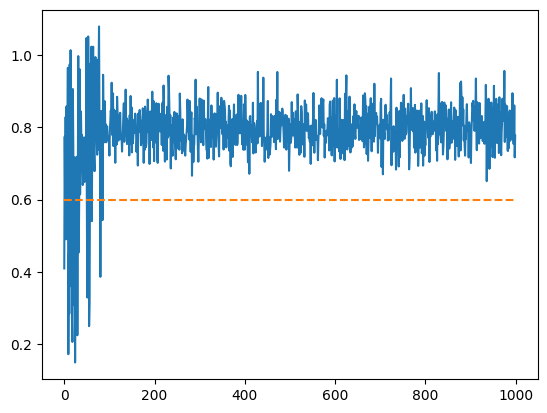

In [ ]:

plt.plot(utility_arr)
plt.plot(np.ones(len(utility_arr))*b,'--')

In [ ]:
plt.figure()
plt.plot(utility_arr, label="Utility")
plt.plot(np.ones(len(utility_arr)) * b, '--', label="Threshold b")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Utility")
plt.title("Utility vs Iteration")

plt.savefig("10arm_utility.pdf", bbox_inches="tight")
plt.close()

In [ ]:
print([np.argmax(actions[i]) for i in range(len(actions))])

[np.int64(2), np.int64(6), np.int64(4), np.int64(8), np.int64(2), np.int64(6), np.int64(3), np.int64(5), np.int64(8), np.int64(0), np.int64(2), np.int64(1), np.int64(9), np.int64(2), np.int64(9), np.int64(6), np.int64(4), np.int64(1), np.int64(0), np.int64(8), np.int64(5), np.int64(1), np.int64(5), np.int64(2), np.int64(0), np.int64(2), np.int64(3), np.int64(6), np.int64(6), np.int64(1), np.int64(3), np.int64(9), np.int64(2), np.int64(3), np.int64(8), np.int64(4), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(3), np.int64(5), np.int64(6), np.int64(6), np.int64(4), np.int64(5), np.int64(4), np.int64(6), np.int64(9), np.int64(3), np.int64(2), np.int64(2), np.int64(9), np.int64(6), np.int64(0), np.int64(0), np.int64(4), np.int64(9), np.int64(6), np.int64(9), np.int64(3), np.int64(6), np.int64(9), np.int64(9), np.int64(8), np.int64(6), np.int64(6), np.int64(6), np.int64(9), np.int64(6), np.int64(8), np.int64(6), np.int64(5), np.int64(9), np.int64(6), np.int64(9)

In [ ]:
print(np.argmax(actions[0]))

2


############   **This is for linear Bandits**   #########################################


In [ ]:
#######################################################################################################################
############   This is for linear Bandits   #########################################
#################################################################################################

# -*- coding: utf-8 -*-
"""
Created on Sat Dec 27 04:42:23 2025

@author: Sourav
"""

import numpy as np
class constrained_KL_reg:
    def __init__(self,beta_r,beta_g,lambda_,tau,rho,kappa,K,ndim,b,actions=None,R=None,U=None,rad=1.0,theta_star_u=None,theta_star_r=None,iters=None):
        self.beta_r = beta_r
        self.beta_g = beta_g
        self.lambda_ = lambda_
        self.tau = tau
        self.rho = rho
        self.kappa = kappa
        self.K = K
        self.ndim = ndim
        self.actions = actions#check if required or not mostly not required.
        self.pi_ref = np.ones(self.ndim)/self.ndim
        self.b = b
        self.R = R
        self.U = U
        self.iters = iters
        self.theta_star_r = theta_star_r
        self.theta_star_u = theta_star_u
        self.rad = rad
    def project(self,z):
      if(np.linalg.norm(z)>self.rad):
        return z*self.rad/np.linalg.norm(z)
      else:
        return z
    def onehot(z):
      ret_val = np.zeros(self.ndim,dtype=int)
      ret_val[int(z)] = 1
      return ret_val
    def Util(self,a,ch=0):
      if ch==0:
        return self.U[a]
      else:
        return np.dot(a,self.theta_star_u)
    def Rew(self,a,ch=0):
      if ch==0:
        return self.R[a]
      else:
        return np.dot(a,self.theta_star_r)
    def special_initialization(self,init_policy=None,Lambda = None,thetar=None,thetag=None):
        if(init_policy==None):
            self.pi = np.ones(self.ndim)/self.ndim
        else:
            self.pi = init_policy

        if(Lambda==None):
            self.Lambda = self.rho*np.eye(len(self.ndim)) #need size here
        else:
            self.Lambda = Lambda
    def calculate_theta(self,a,j):
        a = np.array(a)
        lam_inv = np.linalg.inv(self.Lambda)
        add = np.zeros(len(a[0]))
        for i in range(len(a)):
            add = add + a[i]*j[i]  ###Confirm will it be reward/cost value of theta itself?
        return np.matmul(lam_inv,add)
    def update_policy(self,theta_r,theta_g,ak,ch=0,uch=0):
        if ch==0:
          r_hat = []
          g_hat = []
          for ac in self.actions:
            a = self.one_hot(ac)
            r_hat.append(np.dot(a,theta_r)+self.beta_r*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a))))
            g_hat.append(np.dot(a,theta_g)+self.beta_g*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a))))
          g_expect = np.sum([self.pi[i]*g_hat[i] for i in range(self.ndim)])
          z = (self.b - g_expect)/self.tau
          exp_term = np.exp((r_hat-self.kappa+self.lambda_*self.tau*np.exp(z)*g_hat/(1+np.exp(z)))*1/self.kappa)#Cheeck this term
          pi_new = self.pi_ref*exp_term #Check this term
          pi_new = pi_new/np.sum(pi_new)
        elif ch==1:
          a = ak
          ut = []
          for i in range(self.iters):
            ut.append(self.Util(a,uch))
            a = self.one_hot(np.random.choice(self.ndim,p=self.pi))## change this
          g_expect = np.mean(ut)
          z = (self.b - g_expect)/self.tau
          r_hat = self.Rew(ak,uch)+self.beta_r*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a)))#Add bonus
          g_hat = self.Util(ak,uch)+self.beta_g*np.sqrt(np.dot(np.transpose(a),np.dot(np.linalg.inv(self.Lambda),a))) #Add bonus
          exp_term = np.exp((r_hat-self.kappa+self.lambda_*self.tau*np.exp(z)*g_hat/(1+np.exp(z)))*1/self.kappa)
          pi_new = self.pi_ref*exp_term
          pi_new = pi_new/np.sum(pi_new)
        elif ch == 2:
          ut = []
          for i in range(self.iters):
            a = self.project(np.random.randn(self.ndim))
            ut.append(self.Util(a,uch))
          g_expect = np.mean(ut)
          z = (self.b - g_expect)/self.tau
          r_hat = self.Rew(ak,uch)+self.beta_r*np.sqrt(np.dot(np.transpose(ak),np.dot(np.linalg.inv(self.Lambda),ak))) #Bonus add
          g_hat = self.Util(ak,uch)+self.beta_g*np.sqrt(np.dot(np.transpose(ak),np.dot(np.linalg.inv(self.Lambda),ak))) #Bonus add
          exp_term = np.exp((r_hat-self.kappa+self.lambda_*self.tau*np.exp(z)*g_hat/(1+np.exp(z)))*1/self.kappa)
          pi_new = self.pi_ref*exp_term
          pi_new = pi_new/np.sum(pi_new)
        else:
          print("Invalid choice")
          pi_new = None
        return pi_new
    def run_algo(self):
        action_arr = []
        rew_arr = []
        utility_arr = []
        ch = 0 # 0 for discrete actions 1 for convex bounded structure but action sampled from pi and 2 for parameterized convex but actions sampled from a normal distribution in a closed ball
        uch = 0 # 0 for tabular rewards other wise we have access to theta_star and r(a) = <theta_star,a>
        for k in range(self.K):
            #print(k,"=>",self.pi)
            if(ch==0 or ch==1):
              ak = self.onehot(np.random.choice(self.ndim,p=self.pi))#self.actions[np.random.choice(self.nA,p=self.pi)]
            else:
              ak = self.project(np.random.randn(self.ndim))
            action_arr.append(ak)
            rew_arr.append(self.Rew(ak,uch))
            utility_arr.append(self.Util(ak,uch))
            theta_r,theta_g = self.calculate_theta(action_arr,rew_arr),self.calculate_theta(action_arr,utility_arr)
            #rew_arr.append(r_hat,g_hat)
            self.pi = self.update_policy(theta_r,theta_g,ak,ch,uch)
            self.Lambda = self.Lambda + np.matmul(ak,np.transpose(ak))
        return action_arr,rew_arr,utility_arr

**Case-2 Environment Code (Finite arms + inner product)**

In [ ]:
import numpy as np

def make_case2_toy_env(ndim=10, seed=0):
    """
    Case 2 toy env (NO noise), one-hot features:
      - arms: i = 0..ndim-1
      - action vector a = onehot(i) in R^{ndim}
      - reward  r(a) = <a, theta_star_r>
      - utility g(a) = <a, theta_star_u>
    """
    rng = np.random.default_rng(seed)

    # "actions" list: indices; update_policy will convert each index to one-hot
    actions = list(range(ndim))

    # True parameters (fixed, deterministic)
    # Make one arm clearly best for reward, and some arms better for utility.
    theta_star_r = np.linspace(0.1, 1.0, ndim)          # increasing reward
    theta_star_u = np.linspace(1.0, 0.1, ndim)          # decreasing utility (tradeoff)

    # Constraint threshold on expected utility (tuneable)
    b = 0.7

    return actions, theta_star_r, theta_star_u, b


# quick sanity check
actions, theta_star_r, theta_star_u, b = make_case2_toy_env(ndim=10, seed=0)
print("ndim =", len(actions))
print("theta_star_r[0:5] =", np.round(theta_star_r[:5], 3))
print("theta_star_u[0:5] =", np.round(theta_star_u[:5], 3))
print("b =", b)


ndim = 10
theta_star_r[0:5] = [0.1 0.2 0.3 0.4 0.5]
theta_star_u[0:5] = [1.  0.9 0.8 0.7 0.6]
b = 0.7


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

#######################################################################################################################
############   This is for linear Bandits   #########################################
#################################################################################################

class constrained_KL_reg:
    def __init__(self,beta_r,beta_g,lambda_,tau,rho,kappa,K,ndim,b,actions=None,R=None,U=None,rad=1.0,theta_star_u=None,theta_star_r=None,iters=None):
        self.beta_r = beta_r
        self.beta_g = beta_g
        self.lambda_ = lambda_
        self.tau = tau
        self.rho = rho
        self.kappa = kappa
        self.K = K
        self.ndim = ndim

        # Case-2: actions are indices 0..ndim-1 (we will one-hot them)
        self.actions = actions

        self.pi_ref = np.ones(self.ndim)/self.ndim
        self.b = b

        # In Case-2(inner-product) we will use theta_star_* (not R/U arrays)
        self.R = R
        self.U = U
        self.iters = iters
        self.theta_star_r = theta_star_r
        self.theta_star_u = theta_star_u
        self.rad = rad
        self.dict_r = {} #####========= changes ====================
        self.dict_u = {} #####========= changes ====================

    def project(self,z):
        if(np.linalg.norm(z)>self.rad):
            return z*self.rad/np.linalg.norm(z)
        else:
            return z

    # ---------- BUG FIX (mandatory): add self ----------
    def onehot(self, z):
        ret_val = np.zeros(self.ndim, dtype=float)
        ret_val[int(z)] = 1.0
        return ret_val

    # ---------- BUG FIX (mandatory): alias because code calls one_hot ----------
    def one_hot(self, z):
        return self.onehot(z)

    def Util(self,a,ch=0):
        u_val = 0
        if ch==0:
            # tabular mode (not used in our Case 2 run)
            u_val = self.U[a] #####========= changes ====================
        else:
            # inner product mode (Case 2)
            #act = np.argmax(a)
            u_val =  float(np.dot(a,self.theta_star_u)) #####========= changes ====================
        '''if self.dict_u.get(act)==None: #####========= changes ====================
          self.dict_u[act] = [u_val]  #####========= changes ====================
        else:  #####========= changes ====================
          self.dict_u[act].append(u_val)  #####========= changes ===================='''
        return u_val  #####========= changes ====================

    def Rew(self,a,ch=0):
        r_val = 0
        if ch==0:
            # tabular mode (not used in our Case 2 run)
            r_val =  self.R[a]  #####========= changes ====================
        else:
            # inner product mode (Case 2)
            #act = np.argmax(a)
            r_val = float(np.dot(a,self.theta_star_r))  #####========= changes ====================
        return r_val  #####========= changes ====================

    def special_initialization(self,init_policy=None,Lambda = None,thetar=None,thetag=None):
        if(init_policy==None):
            self.pi = np.ones(self.ndim)/self.ndim
        else:
            self.pi = init_policy

        if(Lambda==None):
            # ---------- BUG FIX (mandatory): len(self.ndim) invalid ----------
            self.Lambda = self.rho*np.eye(self.ndim)
        else:
            self.Lambda = Lambda

    def calculate_theta(self,a,j):
        a = np.array(a, dtype=float)  # (t, d)
        lam_inv = np.linalg.inv(self.Lambda)
        add = np.zeros(len(a[0]), dtype=float)
        for i in range(len(a)):
            add = add + a[i]*float(j[i])
        return np.matmul(lam_inv,add)

    def update_policy(self,theta_r,theta_g,ak,ch=0,uch=0):
        if ch==0:
            r_hat = []
            g_hat = []
            LamInv = np.linalg.inv(self.Lambda)

            for ac in self.actions:
                a = self.one_hot(ac)

                # bonus term: sqrt(a^T LamInv a)
                bonus = np.sqrt(float(a.T @ LamInv @ a))

                r_hat.append(float(np.dot(a,theta_r)) + self.beta_r*bonus)
                g_hat.append(float(np.dot(a,theta_g)) + self.beta_g*bonus)
                if self.dict_r.get(ac)==None:
                    self.dict_r[ac] = [r_hat[-1]]
                    self.dict_u[ac] = [g_hat[-1]]
                else:
                  self.dict_r[ac].append(r_hat[-1])
                  self.dict_u[ac].append(g_hat[-1])

            # ---------- BUG FIX (mandatory): lists -> arrays ----------
            r_hat = np.asarray(r_hat, dtype=float)
            g_hat = np.asarray(g_hat, dtype=float)

            # expected utility under current policy pi
            g_expect = float(np.sum(self.pi * g_hat))

            z = (self.b - g_expect)/self.tau

            # keep your exact form exp(z)/(1+exp(z)) but stable:
            sig = 1.0/(1.0 + np.exp(-z))

            score = (r_hat - self.kappa + self.lambda_*self.tau*sig*g_hat) * (1/self.kappa)

            # numerical stability ONLY (doesn't change mechanism)
            #score = score - np.max(score)

            exp_term = np.exp(score)
            pi_new = self.pi_ref*exp_term
            pi_new = pi_new/np.sum(pi_new)

        elif ch==1:
            # not used (Case 2 only)
            pi_new = None
        elif ch==2:
            # not used (Case 2 only)
            pi_new = None
        else:
            print("Invalid choice")
            pi_new = None
        return pi_new

    def run_algo(self):
        action_arr = []
        rew_arr = []
        utility_arr = []

        # --------- Case 2 only ----------
        ch = 0
        # ---------- BUG FIX (mandatory): inner product mode ----------
        uch = 1
        action_list = []

        for k in range(self.K):
            # choose arm index
            arm_idx = np.random.choice(self.ndim, p=self.pi)

            # represent selected action as one-hot vector
            ak = self.onehot(arm_idx)

            action_arr.append(ak)
            action_list.append(arm_idx)

            # environment feedback (deterministic inner product)
            rew_arr.append(self.Rew(ak, uch))
            utility_arr.append(self.Util(ak, uch))

            # estimate theta from history
            theta_r = self.calculate_theta(action_arr, rew_arr)
            theta_g = self.calculate_theta(action_arr, utility_arr)

            # policy update
            self.pi = self.update_policy(theta_r, theta_g, ak, ch, uch)

            # ---------- BUG FIX (mandatory): correct covariance update ----------
            self.Lambda = self.Lambda + np.outer(ak, ak)
        df_r = pd.DataFrame(self.dict_r)  #####========= changes ====================
        df_u = pd.DataFrame(self.dict_u)  #####========= changes ====================
        df_r.to_excel('Rewards.xlsx')  #####========= changes ====================
        df_u.to_excel('Utlity.xlsx')   #####========= changes ====================
        return action_list,np.array(action_arr), np.array(rew_arr), np.array(utility_arr)


# =========================
# Run Case 2 end-to-end
# =========================
actions, theta_star_r, theta_star_u, b = make_case2_toy_env(ndim=10, seed=0)

agent = constrained_KL_reg(
    beta_r=0.01,#decrease maybe
    beta_g=0.01,#decrease maybe
    lambda_=50.0,#can increase
    tau=0.3,#little less can increase >1
    rho=0.3, # decrease and keep <1 keep 0.4 or 0.3 maybe
    kappa=2.0,#decrease this too high
    K=1000,
    ndim=len(actions),
    b=b,
    actions=actions,
    theta_star_r=theta_star_r,
    theta_star_u=theta_star_u
)

agent.special_initialization()
action_list,A_hist, r_hist, u_hist = agent.run_algo()

print("\nFinal pi =", np.round(agent.pi, 4))
print("Best arm =", int(np.argmax(agent.pi)))
print("Empirical mean reward =", float(np.mean(r_hist)))
print("Empirical mean utility =", float(np.mean(u_hist)))

# Deterministic expected values under final policy:
# For one-hot case: E[r] = sum_i pi[i] * theta_star_r[i], E[u] = sum_i pi[i] * theta_star_u[i]
E_r = float(np.sum(agent.pi * theta_star_r))
E_u = float(np.sum(agent.pi * theta_star_u))
print("\nExpected reward under final pi =", round(E_r, 4))
print("Expected utility under final pi =", round(E_u, 4))
print("Constraint b =", b)
print(Counter(action_list))



Final pi = [0.2654 0.1986 0.1489 0.1115 0.0836 0.0624 0.0469 0.0365 0.0263 0.0198]
Best arm = 0
Empirical mean reward = 0.3316
Empirical mean utility = 0.7684000000000001

Expected reward under final pi = 0.3403
Expected utility under final pi = 0.7597
Constraint b = 0.7
Counter({0: 313, 1: 170, 2: 147, 3: 99, 4: 93, 6: 46, 5: 45, 7: 39, 9: 25, 8: 23})


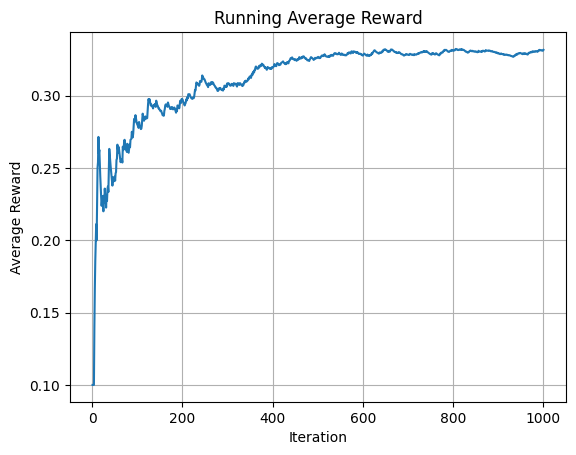

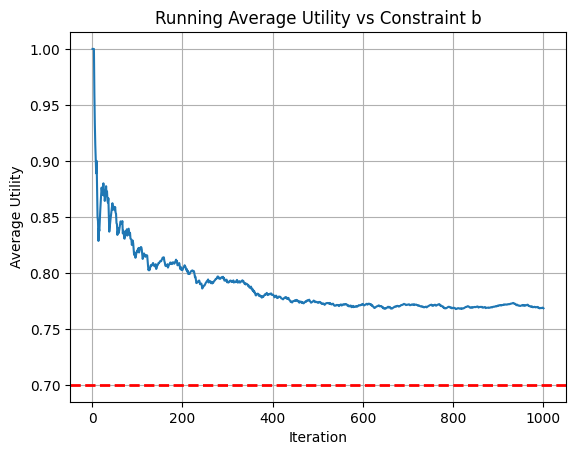

In [ ]:

import matplotlib.pyplot as plt

def running_avg(x):
    x = np.asarray(x, dtype=float)
    return np.cumsum(x) / np.arange(1, len(x) + 1)

t = np.arange(1, len(r_hist)+1)
r_run = running_avg(r_hist)
u_run = running_avg(u_hist)

plt.figure()
plt.plot(t, r_run)
plt.title("Running Average Reward")
plt.xlabel("Iteration"); plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, u_run)
plt.axhline(agent.b, linestyle="--", color='red',linewidth=2)
plt.title("Running Average Utility vs Constraint b")
plt.xlabel("Iteration"); plt.ylabel("Average Utility")
plt.grid(True)
plt.show()

# plt.figure()
# plt.bar(np.arange(agent.ndim), agent.pi)
# plt.title("Final Policy π (Probability per Arm)")
# plt.xlabel("Arm index"); plt.ylabel("Probability")
# plt.grid(True, axis="y")
# plt.show()


**Case-3 Environment Code (Continuous / Infinite actions + inner product)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_case3_toy_env(d=5, rad=1.0, seed=0, b=0.2, normalize_theta=True):
    """
    Case-3 env (NO noise):
      - action a is continuous vector in R^d with ||a|| <= rad
      - reward:  r(a) = <a, theta_star_r>
      - utility: g(a) = <a, theta_star_u>
      - constraint target: E[g(a)] >= b
    """
    rng = np.random.default_rng(seed)

    theta_star_r = rng.normal(size=d)
    theta_star_u = rng.normal(size=d)

    if normalize_theta:
        theta_star_r = theta_star_r / (np.linalg.norm(theta_star_r) + 1e-12)
        theta_star_u = theta_star_u / (np.linalg.norm(theta_star_u) + 1e-12)

    return theta_star_r, theta_star_u, float(b), float(rad)

In [ ]:
# -----------------------------
# code Case-3
# -----------------------------
class constrained_KL_reg:
    def __init__(self, beta_r, beta_g, lambda_, tau, rho, kappa, K, ndim, b,
                 actions=None, R=None, U=None, rad=1.0,
                 theta_star_u=None, theta_star_r=None, iters=200):
        self.beta_r = beta_r
        self.beta_g = beta_g
        self.lambda_ = lambda_
        self.tau = tau
        self.rho = rho
        self.kappa = kappa
        self.K = K
        self.ndim = ndim

        self.actions = actions
        self.pi_ref = np.ones(self.ndim) / self.ndim

        self.b = b
        self.R = R
        self.U = U
        self.iters = iters

        self.theta_star_r = theta_star_r
        self.theta_star_u = theta_star_u
        self.rad = rad

        self.pi = None
        self.Lambda = None

    def project(self, z):
        norm = np.linalg.norm(z)
        if norm > self.rad:
            return z * (self.rad / norm)
        return z

    def Util(self, a, ch=0):
        if ch == 0:
            return self.U[a]
        return float(np.dot(a, self.theta_star_u))

    def Rew(self, a, ch=0):
        if ch == 0:
            return self.R[a]
        return float(np.dot(a, self.theta_star_r))

    def special_initialization(self, init_policy=None, Lambda=None, thetar=None, thetag=None):
        if init_policy is None:
            self.pi = np.ones(self.ndim) / self.ndim
        else:
            self.pi = np.array(init_policy, dtype=float)

        # FIX 1: correct Lambda size
        if Lambda is None:
            self.Lambda = self.rho * np.eye(self.ndim)
        else:
            self.Lambda = np.array(Lambda, dtype=float)

    def calculate_theta(self, a_list, y_list):
        a = np.array(a_list, dtype=float)   # (t, d)
        lam_inv = np.linalg.inv(self.Lambda)
        add = np.zeros(a.shape[1], dtype=float)
        for i in range(len(a)):
            add = add + a[i] * y_list[i]
        return lam_inv @ add

    def update_policy_case3(self, theta_r, theta_g, ak, uch=1):
        # Case-3 branch (same formula as senior code, with z FIX)
        ut = []
        for _ in range(self.iters):
            a = self.project(np.random.randn(self.ndim))
            ut.append(self.Util(a, uch))
        g_expect = float(np.mean(ut))

        # FIX 2: z must exist (you had it commented earlier)
        z = (self.b - g_expect) / self.tau

        Lam_inv = np.linalg.inv(self.Lambda)
        bonus = np.sqrt(float(ak.T @ Lam_inv @ ak))

        r_hat = self.Rew(ak, uch) + self.beta_r * bonus
        g_hat = self.Util(ak, uch) + self.beta_g * bonus

        exp_term = np.exp(
            (r_hat - self.kappa + self.lambda_ * self.tau * np.exp(z) * g_hat / (1.0 + np.exp(z)))
            / self.kappa
        )

        pi_new = self.pi_ref * exp_term
        pi_new = pi_new / np.sum(pi_new)
        return pi_new

    def run_algo_case3(self, seed=0):
        np.random.seed(seed)

        action_arr = []
        rew_arr = []
        util_arr = []
        avg_rew = []
        avg_util = []

        uch = 1  # inner-product mode

        for k in range(self.K):
            # Case-3 action sample ( code style)
            ak = self.project(np.random.randn(self.ndim))

            r = self.Rew(ak, uch)
            u = self.Util(ak, uch)

            action_arr.append(ak)
            rew_arr.append(r)
            util_arr.append(u)

            theta_r = self.calculate_theta(action_arr, rew_arr)
            theta_g = self.calculate_theta(action_arr, util_arr)

            self.pi = self.update_policy_case3(theta_r, theta_g, ak, uch=uch)

            # FIX 3: Lambda update must be outer product (d x d)
            self.Lambda = self.Lambda + np.outer(ak, ak)

            avg_rew.append(float(np.mean(rew_arr)))
            avg_util.append(float(np.mean(util_arr)))

        return rew_arr, util_arr, avg_rew, avg_util


In [ ]:
if __name__ == "__main__":
    # 1) Env (Case-3)
    theta_star_r, theta_star_u, b, rad = make_case3_toy_env(
        d=5, rad=1.0, seed=0, b=0.5, normalize_theta=True
    )

    # 2) Agent
    agent = constrained_KL_reg(
        beta_r=0.01,
        beta_g=0.01,
        lambda_=30.0,
        tau=0.3,
        rho=0.3,
        kappa=3.0,
        K=1000,
        ndim=len(theta_star_r),
        b=b,
        actions=None,
        R=None, U=None,
        rad=rad,
        theta_star_r=theta_star_r,
        theta_star_u=theta_star_u,
        iters=200
    )

    # 3) Init
    agent.special_initialization()

    # 4) Run Case-3
    rewards, utils, avg_rewards, avg_utils = agent.run_algo_case3(seed=0)

    # 5) Quick stats
    print("First 5 rewards:", rewards[:5])
    print("First 5 utils  :", utils[:5])
    print("Mean reward    :", float(np.mean(rewards)))
    print("Mean utility   :", float(np.mean(utils)))
    print("Constraint b   :", b)
    print("Frac steps util > b:", float(np.mean(np.array(utils) > b)))


First 5 rewards: [0.009896784454008378, -0.8115130245233784, 0.41436553526694847, 0.2958845855725989, -0.35929688150010886]
First 5 utils  : [-0.23643655415225495, -0.2868440262061849, -0.43521451401054223, -0.5004145585103369, -0.4519298284053177]
Mean reward    : -0.018339002235976624
Mean utility   : 0.0065523289235012395
Constraint b   : 0.5
Frac steps util > b: 0.176


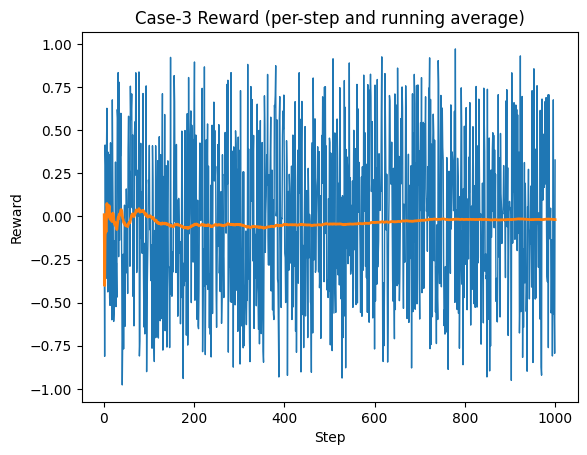

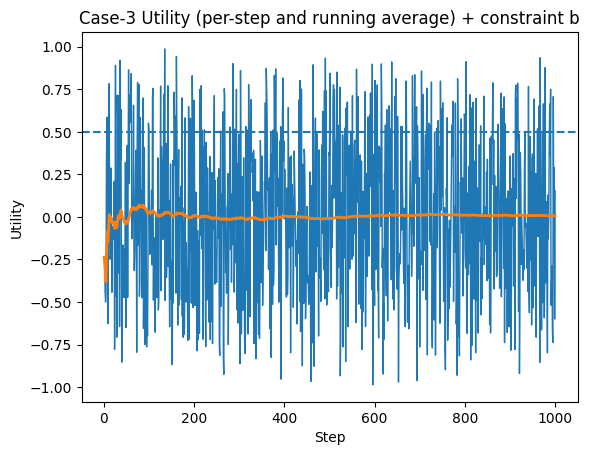

In [ ]:
# 6) Plots
t = np.arange(1, len(rewards) + 1)

# Reward plot
plt.figure()
plt.plot(t, rewards, linewidth=1)
plt.plot(t, avg_rewards, linewidth=2)
plt.xlabel("Step")
plt.ylabel("Reward")
plt.title("Case-3 Reward (per-step and running average)")
plt.show()

# Utility plot
plt.figure()
plt.plot(t, utils, linewidth=1)
plt.plot(t, avg_utils, linewidth=2)
plt.axhline(b, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Utility")
plt.title("Case-3 Utility (per-step and running average) + constraint b")
plt.show()

In [ ]:
class LinUCB:
    def __init__(self, beta, rho, K, ndim, R=None, theta_star=None, rad=1.0):
        self.beta = beta
        self.rho = rho
        self.K = K
        self.ndim = ndim
        self.theta_star = theta_star
        self.rad = rad

        self.Lambda = rho * np.eye(ndim)
        self.b = np.zeros(ndim)

    def project(self, z):
        if np.linalg.norm(z) > self.rad:
            return z * self.rad / np.linalg.norm(z)
        return z

    def onehot(self, z):
        a = np.zeros(self.ndim)
        a[int(z)] = 1.0
        return a

    def Rew(self, a):
        return np.dot(a, self.theta_star)

    def select_action(self, actions=None, ch=0):
        Lambda_inv = np.linalg.inv(self.Lambda)
        theta_hat = Lambda_inv @ self.b

        if ch == 0:  # discrete arms
            best_val = -1e18
            best_a = None
            for i in range(self.ndim):
                a = self.onehot(i)
                val = np.dot(a, theta_hat) + self.beta * np.sqrt(a.T @ Lambda_inv @ a)
                if val > best_val:
                    best_val = val
                    best_a = a
            return best_a

        else:  # continuous convex ball
            a = self.project(np.random.randn(self.ndim))
            for _ in range(200):
                bonus = np.sqrt(a @ Lambda_inv @ a) + 1e-9
                grad = theta_hat + self.beta * (Lambda_inv @ a) / bonus
                a = self.project(a + 0.05 * grad)
            return a

    def run_algo(self, ch=0):
        action_arr, rew_arr = [], []
        for _ in range(self.K):
            a = self.select_action(ch=ch)
            r = self.Rew(a)

            action_arr.append(a)
            rew_arr.append(r)

            self.Lambda += np.outer(a, a)
            self.b += a * r

        return action_arr, rew_arr

##Do not touch this part, it has essence of Contextual bandits for LLM study

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


class PolicyNN(nn.Module):
    def __init__(self, ctx_dim, act_dim, R=1.0):
        super().__init__()
        self.R = R
        self.net = nn.Sequential(
            nn.Linear(ctx_dim, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim)
        )

    def forward(self, x):
        a = self.net(x)
        # project to L2 ball
        norm = torch.norm(a, p=2, dim=-1, keepdim=True) + 1e-9
        a = self.R * a / norm
        return a


class NeuralConstrainedKLLinBandit:
    def __init__(self, d, ctx_dim, R=1.0, rho=1.0,
                 beta_r=1.0, beta_g=1.0,
                 lam=1.0, tau=0.5, b_constraint=0.0,
                 lr=1e-3):

        self.d = d
        self.R = R

        self.Lambda = rho * torch.eye(d)
        self.b_r = torch.zeros(d)
        self.b_g = torch.zeros(d)

        self.beta_r = beta_r
        self.beta_g = beta_g

        self.lam = lam
        self.tau = tau
        self.b_constraint = b_constraint

        self.policy = PolicyNN(ctx_dim, d, R)
        self.opt = optim.Adam(self.policy.parameters(), lr=lr)

    def _phi_grad(self, z):
        return 1 / (1 + torch.exp(-z / self.tau))

    def select_action(self, x):

        Lambda_inv = torch.inverse(self.Lambda)
        theta_r = Lambda_inv @ self.b_r
        theta_g = Lambda_inv @ self.b_g

        # forward pass → action
        a = self.policy(x)

        # compute bonus term
        bonus = torch.sqrt(a @ Lambda_inv @ a.T) + 1e-12

        # compute eta (soft dual variable)
        g_est = a @ theta_g + self.beta_g * bonus
        z = self.b_constraint - g_est.detach()
        eta = self.lam * self._phi_grad(z)

        # compute objective J(ψ)
        r_est = a @ theta_r + self.beta_r * bonus
        J = r_est - eta * g_est

        # gradient ascent on ψ
        self.opt.zero_grad()
        (-J).backward()        # negative because optimizer does descent
        self.opt.step()

        return a.detach()


    def update(self, a, reward, cost):
        self.Lambda += torch.outer(a, a)
        self.b_r += a * reward
        self.b_g += a * cost

In [ ]:
import numpy as np
print(np.linspace(1.0,0.1,10))

[1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]
